In [1]:
import os
import glob
import pandas as pd
import numpy as np
import tifffile


from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import ast
import h5py

from datetime import datetime
import re


# BELOW IS THE MAIN PREPROCESSING CODE

In [2]:
def load_masks_from_directory(mask_dir):
    """
    Load all TIFF binary mask images from a directory.
    Returns a dictionary: subcomponent_name -> 2D boolean numpy array.
    """
    mask_dict = {}
    tiff_files = glob.glob(os.path.join(mask_dir, "*.tif*"))

    for tiff_path in tiff_files:
        filename = os.path.basename(tiff_path)
        # Remove file extension to get subcomponent label (e.g. "node_1" from "node_1.tif")
        subcomponent_name, _ = os.path.splitext(filename)
        
        # Read the binary mask as a 2D numpy array
        mask_array = tifffile.imread(tiff_path)
        
        # Ensure it's boolean
        mask_array = mask_array.astype(bool)
        
        mask_dict[subcomponent_name] = mask_array
    
    return mask_dict


def detect_outliers_by_jump(df, bodypart_names, x_suffix, y_suffix,
                            distance_threshold=None,
                            robust=True, multiplier=3.0):
    """
    Mark body-part positions as NaN if the frame-to-frame jump
    exceeds a distance threshold.
    
    If distance_threshold is None, it is computed from the distribution
    of all distances using either:
      - median + multiplier * MAD (if robust=True), or
      - mean + multiplier * std  (if robust=False).
    """
    df_out = df.copy()

    for bp in bodypart_names:
        x_col = f"{bp}{x_suffix}"
        y_col = f"{bp}{y_suffix}"

        # Skip if columns don't exist
        if x_col not in df_out.columns or y_col not in df_out.columns:
            continue
        
        x_vals = df_out[x_col].values
        y_vals = df_out[y_col].values

        # Calculate frame-to-frame distances
        dx = np.diff(x_vals)
        dy = np.diff(y_vals)
        dist = np.sqrt(dx**2 + dy**2)
        
        # If no threshold provided, auto-compute from the data
        if distance_threshold is None:
            dist_no_nan = dist[~np.isnan(dist)]
            if len(dist_no_nan) == 0:
                # No valid distances, skip
                continue

            if robust:
                # Use median + multiplier * MAD
                median_dist = np.median(dist_no_nan)
                mad = np.median(np.abs(dist_no_nan - median_dist))
                if mad == 0:
                    distance_threshold = median_dist * multiplier
                else:
                    distance_threshold = median_dist + multiplier * mad
            else:
                # mean + multiplier * std
                mean_dist = np.mean(dist_no_nan)
                std_dist = np.std(dist_no_nan)
                distance_threshold = mean_dist + multiplier * std_dist

        # dist[i] is jump from frame i to i+1
        outlier_indices = np.where(dist > distance_threshold)[0] + 1
        # Mark outliers as NaN in the 'destination' frame
        x_vals[outlier_indices] = np.nan
        y_vals[outlier_indices] = np.nan

        df_out[x_col] = x_vals
        df_out[y_col] = y_vals
    
    return df_out


def interpolate_and_smooth_coordinates(df, bodypart_names, x_suffix, y_suffix,
                                       interpolation_method='linear', 
                                       rolling_window=5):
    """
    1) Interpolates NaN values (default 'linear').
    2) Applies a rolling average smoothing over a specified window.
    """
    for bp in bodypart_names:
        x_col = f"{bp}{x_suffix}"
        y_col = f"{bp}{y_suffix}"

        # Skip if missing columns
        if x_col not in df.columns or y_col not in df.columns:
            continue

        # Interpolate: fill internal NaNs from neighbors
        df[x_col] = df[x_col].interpolate(method=interpolation_method, limit_direction='both')
        df[y_col] = df[y_col].interpolate(method=interpolation_method, limit_direction='both')

        # Rolling mean smoothing
        df[x_col] = df[x_col].rolling(window=rolling_window, min_periods=1, center=True).mean()
        df[y_col] = df[y_col].rolling(window=rolling_window, min_periods=1, center=True).mean()

    return df


def estimate_affine_transform(pixel_points, physical_points):
    """
    Estimate the 2x2 matrix A and 2x1 vector b that maps:
        [x_phys, y_phys]^T = A [x_pix, y_pix]^T + b
    using a set of corresponding pixel_points and physical_points.

    pixel_points:   Nx2 array of (x_pix, y_pix)
    physical_points: Nx2 array of (x_phys, y_phys)
    Returns:
        A (2x2 numpy array), b (2x1 numpy array)
    """
    N = pixel_points.shape[0]

    # Build the design matrix M (2N x 6) and vector v (2N x 1).
    # The unknown parameters are [a11, a12, bx, a21, a22, by].
    M = np.zeros((2*N, 6))      
    v = np.zeros((2*N,))

    for i in range(N):
        x_pix, y_pix = pixel_points[i]
        x_phys, y_phys = physical_points[i]

        # x_phys = a11*x_pix + a12*y_pix + bx
        M[2*i, 0] = x_pix
        M[2*i, 1] = y_pix
        M[2*i, 2] = 1.0
        v[2*i]     = x_phys

        # y_phys = a21*x_pix + a22*y_pix + by
        M[2*i+1, 3] = x_pix
        M[2*i+1, 4] = y_pix
        M[2*i+1, 5] = 1.0
        v[2*i+1]    = y_phys

    # Solve in a least squares sense
    solution, residuals, rank, s = np.linalg.lstsq(M, v, rcond=None)
    a11, a12, bx, a21, a22, by = solution

    A = np.array([[a11, a12],
                  [a21, a22]])
    b = np.array([bx, by])

    return A, b

def transform_points(pixel_points, A, b):
    """
    Transform an Nx2 array of pixel_points via the affine transform:
      [x_phys, y_phys]^T = A [x_pix, y_pix]^T + b
    """
    pixel_points = np.asarray(pixel_points)            # shape (N, 2)
    transformed = (A @ pixel_points.T).T + b           # shape (N, 2)
    return transformed


def transform_sleap_dataframe_inplace(df, A, b):
    """
    For each body-part column pair that looks like <part>.x, <part>.y
    in DataFrame df, transform those pixel coordinates in-place to physical (cm).
    i.e., we overwrite the .x, .y columns with the new values.
    
    df: Pandas DataFrame with columns like 'nose.x', 'nose.y', ...
    A, b: affine transform parameters
    """
    # Find all columns ending with ".x".
    x_cols = [col for col in df.columns if col.endswith('.x')]
    
    for x_col in x_cols:
        # Replace '.x' with '.y' to get the matching y column
        y_col = x_col[:-2] + '.y'
        if y_col not in df.columns:
            # If the matching .y doesn't exist, skip
            continue
        
        # Extract Nx2 array of pixel coordinates
        pixel_coords = df[[x_col, y_col]].values
        
        # Transform
        phys_coords = transform_points(pixel_coords, A, b)
        
        # Overwrite the DataFrame columns in-place
        df[x_col] = phys_coords[:, 0]
        df[y_col] = phys_coords[:, 1]
    
    # Return df (not strictly necessary if we modify in-place)
    return df

def compute_head_directions(df, x_suffix=".x", y_suffix=".y"):
    """
    Given a DataFrame that has at least these columns:
        head_mid.x, head_mid.y,
        head_back.x, head_back.y,
        ear_L.x,    ear_L.y,
        ear_R.x,    ear_R.y
    compute two angles per frame:
      - back2mid_deg:  angle from head_back -> head_mid
      - earL2earR_deg: angle from ear_L -> ear_R
    Angles are in degrees, relative to the x-axis, using arctan2 (i.e. [-180, 180] range).

    Returns a new DataFrame of shape (n_frames, 2).
    """
    angles_df = pd.DataFrame(index=df.index, columns=["back2mid_deg", "earL2earR_deg"], dtype=float)

    def angle_deg(x1, y1, x2, y2):
        return np.degrees(np.arctan2(y2 - y1, x2 - x1))

    for i in df.index:
        # Extract the relevant coordinates
        # We do a quick check for any NaNs
        needed_cols = ["head_mid", "head_back", "ear_L", "ear_R"]
        coords = {}
        is_nan = False
        for part in needed_cols:
            xcol = f"{part}{x_suffix}"
            ycol = f"{part}{y_suffix}"
            if (xcol not in df.columns) or (ycol not in df.columns):
                is_nan = True
            else:
                if pd.isna(df.loc[i, xcol]) or pd.isna(df.loc[i, ycol]):
                    is_nan = True
            coords[part] = (df.loc[i, xcol], df.loc[i, ycol])

        if is_nan:
            angles_df.loc[i, ["back2mid_deg", "earL2earR_deg"]] = np.nan
        else:
            (xb, yb) = coords["head_back"]
            (xm, ym) = coords["head_mid"]
            (xl, yl) = coords["ear_L"]
            (xr, yr) = coords["ear_R"]

            # Angle from back -> mid
            back2mid = angle_deg(xb, yb, xm, ym)
            # Angle from left ear -> right ear
            earL2earR = angle_deg(xl, yl, xr, yr)

            angles_df.loc[i, "back2mid_deg"] = back2mid
            angles_df.loc[i, "earL2earR_deg"] = earL2earR

    return angles_df


def map_body_parts_to_subcomponent_h5(
    sleap_h5_path,
    mask_dir,
    output_csv_path,
    # Additional outputs
    cleaned_coords_csv_path="cleaned_coordinates.csv",
    head_direction_csv_path="head_direction.csv",
    # Bodypart parsing
    bodypart_names=None,
    x_suffix=".x",
    y_suffix=".y",
    # Outlier detection params
    outlier_detection=True,
    distance_threshold=None,
    robust=True,
    multiplier=3.0,
    transform_to_physical=False,
    pixel_pts=None,
    physical_pts=None,
    # Interpolation/smoothing params
    interpolation_method='linear',
    rolling_window=5
):
    """
    1) Load SLEAP CSV
    2) Optionally do outlier detection
    3) Interpolate + smooth
    4) Save cleaned coordinates to CSV
    5) Compute head direction from (head_mid, head_back, ear_L, ear_R), save to CSV
    6) Load masks
    7) Map each body-part coordinate to subcomponent, save final mapping

    Args:
        sleap_csv_path: path to the original SLEAP CSV
        mask_dir: directory containing the binary mask TIFF files
        output_csv_path: path for final subcomponent membership CSV
        cleaned_coords_csv_path: path for saving the post-processed (x,y) CSV
        head_direction_csv_path: path for saving the head orientation CSV
        bodypart_names: if None, infer from columns. Otherwise, list of bodypart strings
        x_suffix, y_suffix: how the SLEAP CSV columns are named (default ".x"/".y")
        outlier_detection: whether to remove large jumps
        distance_threshold: pixel threshold for outliers (or None to auto-calc)
        robust: if True and threshold is None, use median+MAD; else mean+std
        multiplier: factor for outlier detection
        interpolation_method: method for pd.DataFrame.interpolate (e.g. 'linear')
        rolling_window: window size for rolling-average smoothing
    """
    # 1) Load SLEAP CSV

        # 1. Load SLEAP HDF5
        # 1. Load SLEAP HDF5

    # with h5py.File(sleap_h5_path, 'r') as f:
    #     tracks = f['tracks'][:]

    #     ##############
    #     bodypart_names = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
    #     print("Bodypart names:", bodypart_names)
        
    #     data = {name: f['tracks'][:, :, i] for i, name in enumerate(bodypart_names)}
    #     print(data['head_mid'].shape)
    #     sleap_df = pd.DataFrame(data)

    with h5py.File(sleap_h5_path, 'r') as f:
        tracks = f['tracks'][:]
        print("Tracks shape:", tracks.shape)  # (tracks, n_frames, n_bodyparts, 2)

        # tracks = np.nanmean(tracks, axis=0)[np.newaxis, :, :, :]  # Take median across videos, keep shape (1, n_frames, n_bodyparts, 2)


        bodypart_names = bodypart_names or list(f['node_names'][:])


        ##############
        bodypart_names_h5 = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
        
        if len(bodypart_names) == 1:
            # Find the index in f['node_names'] where the bodypart name appears

            bodypart_ind = np.where(np.array(bodypart_names_h5) == bodypart_names[0])[0][0]
            
            data = {bodypart_names_h5[0]: tracks[0, :, bodypart_ind, :]}
            
            data_dict = {}
            data_dict[f"{bodypart_names[0]}{x_suffix}"] = tracks[0, 0, bodypart_ind, :]
            data_dict[f"{bodypart_names[0]}{y_suffix}"] = tracks[0, 1, bodypart_ind, :]
        else:
            data = {name: tracks[0, :, i, :] for i, name in enumerate(bodypart_names_h5)}
            data_dict = {}
            for i, bp in enumerate(bodypart_names_h5):
                data_dict[f"{bp}{x_suffix}"] = tracks[0, 0, i, :]
                data_dict[f"{bp}{y_suffix}"] = tracks[0, 1, i, :]
 
        sleap_df = pd.DataFrame(data_dict)
    
    sleap_df_formasks = sleap_df.copy()
    # print(sleap_df_formasks)
    # 2) Identify bodypart names
    # if bodypart_names is None:
    #     x_cols = [col for col in sleap_df.columns if col.endswith(x_suffix)]
    #     bodypart_names = [col.replace(x_suffix, "") for col in x_cols]

    # 3) Outlier detection (optional)
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names,
            x_suffix,
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust,
            multiplier=multiplier
        )

    # 4) Interpolate and smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df,
        bodypart_names,
        x_suffix,
        y_suffix,
        interpolation_method=interpolation_method,
        rolling_window=rolling_window
    )

    # 5 compute affine transform to put into physical coordinates
    if transform_to_physical:
        A, b = estimate_affine_transform(pixel_pts, physical_pts)
        print("Estimated affine matrix A:\n", A)
        print("Estimated translation vector b:\n", b)
        sleap_df = transform_sleap_dataframe_inplace(sleap_df, A, b)

    # ---- (A) SAVE the cleaned coordinates to CSV
    sleap_df.to_csv(cleaned_coords_csv_path, index=False)
    print(f"Cleaned coordinates saved to: {cleaned_coords_csv_path}")

    # 5) Compute head direction angles from head_mid, head_back, ear_L, ear_R
    head_directions_df = compute_head_directions(sleap_df, x_suffix, y_suffix)
    # Save to CSV
    head_directions_df.to_csv(head_direction_csv_path, index=False)
    print(f"Head direction angles saved to: {head_direction_csv_path}")

    # 6) Load the binary mask TIFFs
    masks = load_masks_from_directory(mask_dir)
    # We assume all masks share the same shape
    mask_shape = None
    if len(masks) > 0:
        key = next(iter(masks.keys()))
        mask_shape = masks[key].shape

    # 7) Map each coordinate to subcomponent
    out_subcomp_df = pd.DataFrame(index=sleap_df_formasks.index, columns=bodypart_names_h5, dtype=object)
    for i, row_data in sleap_df_formasks.iterrows():
        for bp in bodypart_names_h5:
            x_col = f"{bp}{x_suffix}"
            y_col = f"{bp}{y_suffix}"

            if x_col not in sleap_df_formasks.columns or y_col not in sleap_df_formasks.columns:
                out_subcomp_df.at[i, bp] = "None"
                continue

            x_coord = row_data[x_col]
            y_coord = row_data[y_col]

            # If still NaN, label as "None"
            if pd.isna(x_coord) or pd.isna(y_coord):
                out_subcomp_df.at[i, bp] = "None"
                continue
            
            x_idx = int(round(x_coord))
            y_idx = int(round(y_coord))

            # Check if out of bounds
            if mask_shape is not None:
                h, w = mask_shape
                if x_idx < 0 or x_idx >= w or y_idx < 0 or y_idx >= h:
                    out_subcomp_df.at[i, bp] = "None"
                    continue

            # Identify which mask is True
            found_subcomponent = False
            for subcomp_name, mask_arr in masks.items():
                if mask_arr[y_idx, x_idx]:
                    out_subcomp_df.at[i, bp] = subcomp_name
                    found_subcomponent = True
                    break
            if not found_subcomponent:
                out_subcomp_df.at[i, bp] = "None"

    # 8) Save final subcomponent membership
    out_subcomp_df.to_csv(output_csv_path, index=False)
    print(f"Subcomponent mapping saved to: {output_csv_path}")




def get_date_from_filename(filename):
    """
    Extracts a date object from a filename string that contains a date
    in YYYY-MM-DD format.
    Example: "..._2024-03-25-123456..." -> datetime.date(2024, 3, 25)
    Returns None if no date is found.
    """
    match = re.search(r'(\d{4}-\d{2}-\d{2})', filename)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y-%m-%d').date()
    return None

def is_early_recording(filename, cutoff_date):
    """
    Check if the recording in the filename is before the cutoff date.
    Returns True if early, False otherwise.
    """
    date = get_date_from_filename(filename)
    if date is None:
        return False  # No date found, assume not early
    return date <= cutoff_date



In [ ]:
test_filename = "bp04-2024-03-25-100959.txt"
get_date_from_filename(test_filename)
# see if date occurs before the cutoff date

# Example usage
is_early_recording(test_filename, datetime(2024, 3, 25).date())

True

In [1]:


# folder = r'/Users/AdamHarris/Documents/cohort7_SLEAP_preprocess_July2025/mEC_SLEAP/h5/early_masks'
folder = 'mEC_data/maze'
mEC_bp01_masks_switch_date = datetime(2024, 3, 25).date() #26th date is all over the place, so we use 25th as cutoff date and only data from 28 onwards downsrteam

"""
coordinates in cm of the maze corners
"""
physical_pts = np.array([[0, 0],
                        [47, 0],
                        [47, 47],
                        [0, 47]])


"""
below is for mEC cohort bp01
early = up to 2024-03-25
late = after 2024-03-25
"""
maze_1_late_pixel_pts = np.array([[1109, 826],
                                [908, -5], 
                                [72, 174], 
                                [254, 1028]])

maze_1_early_pixel_pts = np.array([[1208, 840],
                                    [989, 25], 
                                    [184, 213], 
                                    [376, 1030]])

"""
below is for mEC cohort bp04
"""

maze_2_pixel_pts_mEC = np.array([[256, 944],     #node 1
                                [1034, 944],   #node 3
                                [260, 182],    #node 7
                                [1009, 166]])  #node 9




"""
below is for lEC cohort
"""



maze_1_pixel_pt_lEC = np.array([[1022, 974],
                            [981, 136],
                            [158, 169],
                            [172, 1010]])

maze_2_pixel_pts_lEC = np.array([[234, 945],
                            [1036, 953],
                            [1020, 158],
                            [248, 169]])


# Define the cutoff date for distinguishing 'early' vs 'late' recordings for bp01
# Recordings on or before this date are 'early'




for filename in tqdm(os.listdir(folder)):
    
    if not filename.endswith(".h5"):
        continue

    if 'bp04' in filename:
        masks_directory = "masks/mEC_maze2"
        pixel_points = maze_2_pixel_pts_mEC
        output_csv_path = f"mEC_preprocessed/maze/bp04/{filename[-34:-3]}_ROIs.csv"
        cleaned_coords_csv_path = f"mEC_preprocessed/maze/bp04/{filename[-34:-3]}_cleaned_coordinates.csv"
        head_direction_csv_path = f"mEC_preprocessed/maze/bp04/{filename[-34:-3]}_head_direction.csv"

    if 'bp02' in filename:
        masks_directory = "masks/mEC_maze2"
        pixel_points = maze_2_pixel_pts_mEC
        output_csv_path = f"mEC_preprocessed/maze/bp02/{filename[-34:-3]}_ROIs.csv"
        cleaned_coords_csv_path = f"mEC_preprocessed/maze/bp02/{filename[-34:-3]}_cleaned_coordinates.csv"
        head_direction_csv_path = f"mEC_preprocessed/maze/bp02/{filename[-34:-3]}_head_direction.csv"
    
    if 'bp01' in filename:
        if is_early_recording(filename, mEC_bp01_masks_switch_date):
            masks_directory = "masks/mEC_maze1_early"
            pixel_points = maze_1_early_pixel_pts
            output_csv_path = f"mEC_preprocessed/maze/bp01/{filename[-34:-3]}_ROIs.csv"
            cleaned_coords_csv_path = f"mEC_preprocessed/maze/bp01/{filename[-34:-3]}_cleaned_coordinates.csv"
            head_direction_csv_path = f"mEC_preprocessed/maze/bp01/{filename[-34:-3]}_head_direction.csv"
        else:
            masks_directory = "masks/mEC_maze1_late"
            pixel_points = maze_1_late_pixel_pts
            output_csv_path = f"mEC_preprocessed/maze/bp01/{filename[-34:-3]}_ROIs.csv"
            cleaned_coords_csv_path = f"mEC_preprocessed/maze/bp01/{filename[-34:-3]}_cleaned_coordinates.csv"
            head_direction_csv_path = f"mEC_preprocessed/maze/bp01/{filename[-34:-3]}_head_direction.csv"
    else:
        print(f"Skipping {filename} as it does not match expected patterns for bp01 or bp04.")
        continue
    
        
    sleap_h5 = os.path.join(folder, filename)
    print(f"now working with {sleap_h5}")
  
    map_body_parts_to_subcomponent_h5(
        sleap_h5_path=sleap_h5,
        mask_dir=masks_directory,
        output_csv_path=output_csv_path,
        cleaned_coords_csv_path=cleaned_coords_csv_path,
        head_direction_csv_path=head_direction_csv_path,
        bodypart_names=None, #["head_mid", "head_back", "ear_L", "ear_R"],
        x_suffix=".x",
        y_suffix=".y",
        outlier_detection=True,
        distance_threshold=None,   # auto-compute
        robust=True,              # median+MAD approach
        multiplier=3.0,
        transform_to_physical=True,
        pixel_pts=pixel_points,
        physical_pts=physical_pts,
        interpolation_method='linear',
        rolling_window=5
    )



NameError: name 'datetime' is not defined

In [14]:


# folder = r'/Users/AdamHarris/Documents/cohort7_SLEAP_preprocess_July2025/mEC_SLEAP/h5/early_masks'
folder = 'lEC_data/maze'


"""
coordinates in cm of the maze corners
"""
physical_pts = np.array([[0, 0],
                        [47, 0],
                        [47, 47],
                        [0, 47]])


"""
below is for mEC cohort bp01
early = up to 2024-03-25
late = after 2024-03-25
"""
maze_1_late_pixel_pts = np.array([[1109, 826],
                                [908, -5], 
                                [72, 174], 
                                [254, 1028]])

maze_1_early_pixel_pts = np.array([[1208, 840],
                                    [989, 25], 
                                    [184, 213], 
                                    [376, 1030]])

"""
below is for mEC cohort bp04
"""

maze_2_pixel_pts_mEC = np.array([[256, 944],     #node 1
                                [1034, 944],   #node 3
                                [260, 182],    #node 7
                                [1009, 166]])  #node 9




"""
below is for lEC cohort
"""



maze_1_pixel_pt_lEC = np.array([[1022, 974],
                            [981, 136],
                            [158, 169],
                            [172, 1010]])

maze_2_pixel_pts_lEC = np.array([[234, 945],
                            [1036, 953],
                            [1020, 158],
                            [248, 169]])


# Define the cutoff date for distinguishing 'early' vs 'late' recordings for bp01
# Recordings on or before this date are 'early'


maze_1_mice = ['ly07', 'ly05', 'ah10']
maze_2_mice = ['ly06', 'ah08']

for filename in tqdm(os.listdir(folder)):
    
    if not filename.endswith(".h5"):
        continue



    mouse_id = None
    found_mouse = False
    filename_trimmed = filename[-34:-3]  # Remove the .h5 extension and stuff about the slp file

    for mouse in maze_1_mice:
        if mouse in filename_trimmed:
            mouse_id = mouse
            masks_directory = "masks/lEC_maze1"
            pixel_points = maze_1_pixel_pt_lEC
            found_mouse = True
            break
    
    if not found_mouse:
        for mouse in maze_2_mice:
            if mouse in filename_trimmed:
                mouse_id = mouse
                masks_directory = "masks/lEC_maze2"
                pixel_points = maze_2_pixel_pts_lEC
                found_mouse = True
                break

    if not found_mouse:
        print(f"Skipping {filename} as it does not match any known mouse ID.")
        continue

    # Create output directories if they don't exist
    output_dir = f"lEC_preprocessed/maze/{mouse_id}"
    os.makedirs(output_dir, exist_ok=True)

    # Define output paths
    base_name = filename[-34:-3]  # Remove the .h5 extension
    output_csv_path = os.path.join(output_dir, f"{base_name}_ROIs.csv")
    cleaned_coords_csv_path = os.path.join(output_dir, f"{base_name}_cleaned_coordinates.csv")
    head_direction_csv_path = os.path.join(output_dir, f"{base_name}_head_direction.csv")
    
    # Check if all output files already exist
    if (os.path.exists(output_csv_path) and
        os.path.exists(cleaned_coords_csv_path) and
        os.path.exists(head_direction_csv_path)):
        print(f"Skipping {filename}, output files already exist.")
        continue

    sleap_h5 = os.path.join(folder, filename)
    print(f"now working with {sleap_h5}")
  
    try:
        map_body_parts_to_subcomponent_h5(
            sleap_h5_path=sleap_h5,
            mask_dir=masks_directory,
            output_csv_path=output_csv_path,
            cleaned_coords_csv_path=cleaned_coords_csv_path,
            head_direction_csv_path=head_direction_csv_path,
            bodypart_names=None, #["head_mid", "head_back", "ear_L", "ear_R"],
            x_suffix=".x",
            y_suffix=".y",
            outlier_detection=True,
            distance_threshold=None,   # auto-compute
            robust=True,              # median+MAD approach
            multiplier=3.0,
            transform_to_physical=True,
            pixel_pts=pixel_points,
            physical_pts=physical_pts,
            interpolation_method='linear',
            rolling_window=5
        )
    except Exception as e:
        print(f"Error processing {filename}: {e}")
        continue




  0%|          | 0/932 [00:00<?, ?it/s]

now working with lEC_data/maze/ah08_implanted.035_ah08_2025-06-13-151332.analysis.h5
Tracks shape: (1, 2, 8, 75222)
Estimated affine matrix A:
 [[ 5.96986375e-02 -8.98166375e-05]
 [-1.00236375e-04 -5.98255725e-02]]
Estimated translation vector b:
 [-14.32882501  56.84157468]
Cleaned coordinates saved to: lEC_preprocessed/maze/ah08/ah08_2025-06-13-151332.analysis_cleaned_coordinates.csv
Head direction angles saved to: lEC_preprocessed/maze/ah08/ah08_2025-06-13-151332.analysis_head_direction.csv


  0%|          | 1/932 [01:00<15:38:45, 60.50s/it]

Subcomponent mapping saved to: lEC_preprocessed/maze/ah08/ah08_2025-06-13-151332.analysis_ROIs.csv
now working with lEC_data/maze/ly06_ly07_implanted.045_ly06_2025-06-17-122126.analysis.h5
Tracks shape: (1, 2, 8, 75375)
Estimated affine matrix A:
 [[ 5.96986375e-02 -8.98166375e-05]
 [-1.00236375e-04 -5.98255725e-02]]
Estimated translation vector b:
 [-14.32882501  56.84157468]
Cleaned coordinates saved to: lEC_preprocessed/maze/ly06/ly06_2025-06-17-122126.analysis_cleaned_coordinates.csv
Head direction angles saved to: lEC_preprocessed/maze/ly06/ly06_2025-06-17-122126.analysis_head_direction.csv


  0%|          | 2/932 [02:01<15:46:23, 61.06s/it]

...

Subcomponent mapping saved to: lEC_preprocessed/maze/ly05/ly05_2025-06-04-170606.analysis_ROIs.csv
now working with lEC_data/maze/ah08_implanted.009_ah08_2025-06-06-140124.analysis.h5
Tracks shape: (1, 2, 8, 86715)
Estimated affine matrix A:
 [[ 5.96986375e-02 -8.98166375e-05]
 [-1.00236375e-04 -5.98255725e-02]]
Estimated translation vector b:
 [-14.32882501  56.84157468]
Cleaned coordinates saved to: lEC_preprocessed/maze/ah08/ah08_2025-06-06-140124.analysis_cleaned_coordinates.csv
Head direction angles saved to: lEC_preprocessed/maze/ah08/ah08_2025-06-06-140124.analysis_head_direction.csv


100%|█████████▉| 929/932 [5:51:03<01:04, 21.51s/it]

Subcomponent mapping saved to: lEC_preprocessed/maze/ah08/ah08_2025-06-06-140124.analysis_ROIs.csv
now working with lEC_data/maze/ly06_ly07_implanted.125_ly07_2025-06-18-151938.analysis.h5
Tracks shape: (1, 2, 8, 79588)
Estimated affine matrix A:
 [[-0.00230693 -0.05591007]
 [-0.05609605  0.00183656]]
Estimated translation vector b:
 [56.8400542  55.16705127]
Cleaned coordinates saved to: lEC_preprocessed/maze/ly07/ly07_2025-06-18-151938.analysis_cleaned_coordinates.csv
Head direction angles saved to: lEC_preprocessed/maze/ly07/ly07_2025-06-18-151938.analysis_head_direction.csv


100%|██████████| 932/932 [5:51:43<00:00, 22.64s/it]

Subcomponent mapping saved to: lEC_preprocessed/maze/ly07/ly07_2025-06-18-151938.analysis_ROIs.csv


In [ ]:
import h5py
import pandas as pd
 
def map_body_parts_to_subcomponent(sleap_h5_path, 
                                   mask_dir, 
                                   output_csv_path, 
                                   bodypart_names=None, 
                                   x_suffix="_x", 
                                   y_suffix="_y",
                                   # Outlier detection parameters
                                   outlier_detection=True,
                                   distance_threshold=None,
                                   robust=True,
                                   multiplier=3.0,
                                   # Interpolation & smoothing parameters
                                   interpolation_method='linear',
                                   rolling_window=5):
    """
    1) Loads SLEAP HDF5 of body part coordinates
    2) Optionally detects & removes large jump outliers
    3) Interpolates + smooths
    4) Loads TIFF binary masks
    5) Maps each body part's (x,y) to a subcomponent
    6) Exports the final mapping in a CSV
    
    Args:
        sleap_h5_path (str): Path to the SLEAP HDF5 file.
        mask_dir (str): Directory containing the binary mask TIFF files.
        output_csv_path (str): Path for saving the output CSV.
        bodypart_names (list): If None, the code will infer from HDF5 dataset names.
        x_suffix (str): Suffix for x coordinates (default "_x").
        y_suffix (str): Suffix for y coordinates (default "_y").
        
        outlier_detection (bool): Whether to do outlier detection by large jumps.
        distance_threshold (float or None): If float, fixed threshold in pixels. If None, auto-calc from data.
        robust (bool): If True and threshold is None, use median+MAD approach; else use mean+std.
        multiplier (float): Multiplier for outlier detection threshold.
        
        interpolation_method (str): Pandas interpolation method (e.g., 'linear', 'time', 'polynomial', etc.).
        rolling_window (int): Window size for rolling average smoothing.
    """
    # 1. Load SLEAP HDF5
    with h5py.File(sleap_h5_path, 'r') as f:
        tracks = f['tracks'][:]
        bodypart_names_pre_parse = bodypart_names or list(f['node_names'][:])

        ##############
        bodypart_names = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
        
        
        data = {name: f['tracks'][:, :, i] for i, name in enumerate(bodypart_names)}
        sleap_df = pd.DataFrame(data)
    
    # 2. Outlier detection & removal
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names, 
            x_suffix, 
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust, 
            multiplier=multiplier
        )

    # 3. Interpolate & smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df, 
        bodypart_names, 
        x_suffix, 
        y_suffix,
        interpolation_method=interpolation_method, 
        rolling_window=rolling_window
    )

    # 4. Load binary masks
    masks = load_masks_from_directory(mask_dir)
    # We assume consistent shape
    mask_shape = None
    if len(masks) > 0:
        first_key = next(iter(masks.keys()))
        mask_shape = masks[first_key].shape

    # 5. Map each body part to subcomponent
    output_df = pd.DataFrame(index=sleap_df.index, columns=bodypart_names, dtype=object)

    for i, row_data in sleap_df.iterrows():
        for bp in bodypart_names:
            x_col = f"{bp}{x_suffix}"
            y_col = f"{bp}{y_suffix}"

            if x_col not in sleap_df.columns or y_col not in sleap_df.columns:
                output_df.at[i, bp] = "None"
                continue

            x_coord = row_data[x_col]
            y_coord = row_data[y_col]

            if pd.isna(x_coord) or pd.isna(y_coord):
                output_df.at[i, bp] = "None"
                continue
            
            x_idx = int(round(x_coord))
            y_idx = int(round(y_coord))

            # Check bounds
            if mask_shape is not None:
                h, w = mask_shape
                if x_idx < 0 or x_idx >= w or y_idx < 0 or y_idx >= h:
                    output_df.at[i, bp] = "None"
                    continue

            # Identify which mask is True
            found_subcomponent = False
            for subcomp_name, mask_arr in masks.items():
                if mask_arr[y_idx, x_idx]:
                    output_df.at[i, bp] = subcomp_name
                    found_subcomponent = True
                    break
            if not found_subcomponent:
                output_df.at[i, bp] = "None"

    # 6. Save final output
    output_df.to_csv(output_csv_path, index=False)
    print(f"Output saved to: {output_csv_path}")


# code below is for checking missing frames from sleap outputs. CSV vs hdf5 formats


In [ ]:
import os
import pandas as pd

folder = "/Users/AdamHarris/Desktop/cohort_10_exploration/maze1"

for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        df = pd.read_csv(file_path)
        print(f"{filename}: {len(df)} rows")

In [ ]:
import os
import pandas as pd
import cv2

vids_paths = '/Users/AdamHarris/Desktop/exploration_videos'
folder = "/Users/AdamHarris/Desktop/cohort_10_exploration/maze1"
folder2 = "/Users/AdamHarris/Desktop/cohort_10_exploration/maze2"
def get_video_frame_count(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return frame_count

def format_missing_frames(missing_frames):
    sorted_frames = sorted(missing_frames)
    ranges = []
    start = end = sorted_frames[0]

    for frame in sorted_frames[1:]:
        if frame == end + 1:
            end = frame
        else:
            if start == end:
                ranges.append(f"{start}")
            else:
                ranges.append(f"{start}-{end}")
            start = end = frame

    if start == end:
        ranges.append(f"{start}")
    else:
        ranges.append(f"{start}-{end}")

    return ", ".join(ranges)

for folder in [folder, folder2]:

    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder, filename)
            df = pd.read_csv(file_path)
            
            # Extract mouse ID and datetime string from filename
            parts = filename.split('_')
            mouse_id = parts[1]
            datetime_str = parts[2].split('.')[0]
            
            # Find the corresponding video file
            video_filename = f"{mouse_id}_{datetime_str}.mp4"
            video_path = os.path.join(vids_paths, video_filename)
            
            if os.path.exists(video_path):
                total_frames = get_video_frame_count(video_path)
                print(f"{filename}: {len(df)} rows, {total_frames} frames in video | {total_frames - len(df)} frames missing.  {(total_frames - len(df))/60:.2f} seconds")

                # Check for missing frames
                csv_frames = set(df['frame_idx'])
                video_frames = set(range(total_frames))
                missing_frames = video_frames - csv_frames
                
                if missing_frames:
                    formatted_missing_frames = format_missing_frames(missing_frames)
                    print(f"Missing frames in {filename}: {formatted_missing_frames}")
                else:
                    print(f"No missing frames in {filename}")
            else:
                print(f"Video file not found for {filename}")

In [ ]:
xx = h5py.File(h5_path, 'r')
xx['tracks'][0,0,0,:].shape

In [39]:
import h5py

comparisons_dir = "/Users/AdamHarris/Desktop/bp01_c7_h5_csv"
comparisons_dir = "/Users/AdamHarris/Desktop/openfield_sleap"
comparisons_dir = "/Users/AdamHarris/Desktop/objectvector_sleap"

for filename in os.listdir(comparisons_dir):
    if filename.endswith(".csv"):
        csv_path = os.path.join(comparisons_dir, filename)
        h5_path = os.path.join(comparisons_dir, filename.replace(".csv", ".h5"))

        if os.path.exists(h5_path):
            # Load CSV
            csv_df = pd.read_csv(csv_path)
            csv_count = len(csv_df)

            # Load H5
            with h5py.File(h5_path, 'r') as h5_file:
                h5_count = len(h5_file['tracks'][0,0,0,:])

            # Print the counts and the difference
            print(f"{filename}: CSV entries = {csv_count}, H5 entries = {h5_count}, Difference = {(h5_count-csv_count)/60} seconds")
        else:
            print(f"H5 file not found for {filename}")

labels.v004.003_bp01_2024-03-25-153209.analysis.csv: CSV entries = 107984, H5 entries = 109864, Difference = 31.333333333333332 seconds
labels.v004.002_bp01_2024-03-18-191403.analysis.csv: CSV entries = 109240, H5 entries = 110548, Difference = 21.8 seconds
labels.v004.000_bp01_2024-03-17-140534.analysis.csv: CSV entries = 113673, H5 entries = 114230, Difference = 9.283333333333333 seconds
labels.v004.001_bp01_2024-03-18-191241.analysis.csv: CSV entries = 4514, H5 entries = 4611, Difference = 1.6166666666666667 seconds
labels.v004.005_bp01_2024-04-03-155448.analysis.csv: CSV entries = 110610, H5 entries = 110755, Difference = 2.4166666666666665 seconds
labels.v004.004_bp01_2024-03-26-191116.analysis.csv: CSV entries = 110387, H5 entries = 110679, Difference = 4.866666666666666 seconds


In [ ]:
with h5py.File(h5_path, 'r') as h5_file:
    h5_count = len(h5_file['tracks'][0,0,0:])

In [ ]:
xxx = h5py.File(h5_path, 'r')

In [ ]:
xxx.keys()

In [ ]:
import matplotlib.pyplot as plt

test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/cohort_10_exploration/processed/c1m3_2025-03-12-121432.analysis_cleaned_coordinates.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.2, c='grey')
ax.invert_yaxis()
plt.show()

test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/cohort_10_exploration/processed/c1m4_2025-03-12-121432.analysis_cleaned_coordinates.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.2, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/mEC_SLEAP/outputs/bp01_2024-03-21-125921.analysis_cleaned_coordinates.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
test_coords_df = pd.read_csv("/Users/AdamHarris/Desktop/analysis/labels.v004.000_bp01_2024-03-17-140534.analysis.csv")
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()


In [ ]:
test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/analysis 2/labels.v003.000_bp01_2024-03-15-144543.analysis.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()



In [ ]:
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [2]:
import numpy as np
import cv2
import pandas as pd

def calibrate_and_correct(
    pixel_points: np.ndarray,
    world_points: np.ndarray,
    image_size: tuple,
    flags: int = None
):
    """
    Calibrate camera for radial (and possibly tangential) distortion
    based on 2D correspondences, then return camera matrix and distortion coefficients.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of pixel coordinates (image points).
    world_points : np.ndarray
        Nx2 array of corresponding physical coordinates (in real-world space, 2D).
    image_size : tuple
        (width, height) of the image in pixels.
    flags : int, optional
        OpenCV flags to refine calibration method. 
        E.g. cv2.CALIB_FIX_ASPECT_RATIO, etc.
    
    Returns
    -------
    camera_matrix : np.ndarray
        The computed camera intrinsic matrix.
    dist_coeffs : np.ndarray
        Distortion coefficients (k1, k2, p1, p2, k3, ...).
    rvecs : list
        Rotation vectors from the calibration routine.
    tvecs : list
        Translation vectors from the calibration routine.
    """
    # We need these in the format (N, 1, 2) for cv2.calibrateCamera
    pixel_points_reshaped = pixel_points.reshape(-1, 1, 2).astype(np.float32)
    world_points_reshaped = world_points.reshape(-1, 1, 2).astype(np.float32)
    
    # Because we're doing a planar approximation, we can treat the real-world points as if z=0
    # However, OpenCV calibrateCamera expects 3D object points for the real-world coords.
    # So let's just embed them in 3D as (x, y, 0).
    object_points_3d = np.hstack([world_points, np.zeros((world_points.shape[0], 1))])
    object_points_3d = object_points_3d.reshape(-1, 1, 3).astype(np.float32)
    
    # We must pass a list of arrays: each array is the correspondences for a single view.
    # If we have only one set of correspondences, it's like we have 1 "image" of that plane.
    object_points_list = [object_points_3d]
    image_points_list = [pixel_points_reshaped]
    
    # Initialize a guess for the camera matrix
    # fx ~ fy ~ some fraction of image size, and principal point near the center
    focal_length = 0.8 * image_size[0]
    cx, cy = image_size[0] / 2.0, image_size[1] / 2.0
    camera_matrix_init = np.array([[focal_length, 0, cx],
                                   [0, focal_length, cy],
                                   [0,           0,  1]], dtype=np.float32)
    
    dist_coeffs_init = np.zeros(5)  # [k1, k2, p1, p2, k3] etc.
    
    if flags is None:
        # Default to something that tries to solve k1, k2, p1, p2, k3
        flags = 0

    # calibrateCamera returns:
    #   rms_error, camera_matrix, dist_coeffs, rvecs, tvecs
    rms, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        object_points_list,
        image_points_list,
        image_size,
        camera_matrix_init,
        dist_coeffs_init,
        flags=flags
    )
    
    print(f"Calibration RMS re-projection error: {rms:.4f}")
    print("Camera Matrix:\n", camera_matrix)
    print("Distortion Coeffs:\n", dist_coeffs.ravel())
    
    return camera_matrix, dist_coeffs, rvecs, tvecs

def undistort_points(
    pixel_points: np.ndarray,
    camera_matrix: np.ndarray,
    dist_coeffs: np.ndarray
) -> np.ndarray:
    """
    Undistort pixel points given the camera matrix and distortion coefficients.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of pixel coordinates.
    camera_matrix : np.ndarray
        3x3 intrinsic camera matrix.
    dist_coeffs : np.ndarray
        Distortion coefficients.
    
    Returns
    -------
    undistorted_points : np.ndarray
        Nx2 array of undistorted (corrected) pixel coordinates.
    """
    # reshape for OpenCV
    points_reshaped = pixel_points.reshape(-1, 1, 2).astype(np.float32)
    
    # Undistort
    undistorted = cv2.undistortPoints(points_reshaped, camera_matrix, dist_coeffs, P=camera_matrix)
    
    # undistorted returns Nx1x2
    undistorted = undistorted.reshape(-1, 2)
    return undistorted

def find_planar_homography(
    pixel_points: np.ndarray,
    world_points: np.ndarray
) -> np.ndarray:
    """
    Estimate a 3x3 homography matrix mapping 2D pixel space to 2D physical world space.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of (x, y) pixel coordinates.
    world_points : np.ndarray
        Nx2 array of (x, y) physical coordinates in the real world.
        
    Returns
    -------
    H : np.ndarray
        3x3 homography matrix that maps from pixel to physical coordinates.
    """
    # Need float32 for OpenCV
    pixel_points_32 = pixel_points.reshape(-1, 1, 2).astype(np.float32)
    world_points_32 = world_points.reshape(-1, 1, 2).astype(np.float32)
    
    H, mask = cv2.findHomography(pixel_points_32, world_points_32, cv2.RANSAC, 5.0)
    
    return H

def transform_points_homography(
    pixel_points: np.ndarray,
    H: np.ndarray
) -> np.ndarray:
    """
    Apply a 3x3 homography transform to a set of 2D pixel points.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of pixel coordinates.
    H : np.ndarray
        3x3 homography matrix.
    
    Returns
    -------
    physical_points : np.ndarray
        Nx2 array of physical coordinates.
    """
    # Convert to homogeneous coordinates: (x, y, 1)
    n = pixel_points.shape[0]
    ones = np.ones((n, 1))
    pixel_points_h = np.hstack([pixel_points, ones])
    
    # Transform
    transformed = (H @ pixel_points_h.T).T  # shape Nx3
    
    # Convert back from homogeneous
    transformed_xy = transformed[:, :2] / transformed[:, 2][:, np.newaxis]
    return transformed_xy


def transform_sleap_dataframe_inplace_radialdistortion(df,  camera_matrix, dist_coeffs, pixel_points, world_points):
    """
    For each body-part column pair that looks like <part>.x, <part>.y
    in DataFrame df, transform those pixel coordinates in-place to physical (cm).
    i.e., we overwrite the .x, .y columns with the new values.
    
    df: Pandas DataFrame with columns like 'nose.x', 'nose.y', ...
    camera_matrix, dist_coeffs: camera calibration parameters
    """
    # Find all columns ending with ".x".
    x_cols = [col for col in df.columns if col.endswith('.x')]
    
    for x_col in x_cols:
        # Replace '.x' with '.y' to get the matching y column
        y_col = x_col[:-2] + '.y'
        if y_col not in df.columns:
            # If the matching .y doesn't exist, skip
            continue
        
        # Extract Nx2 array of pixel coordinates
        pixel_coords = df[[x_col, y_col]].values
        
        # Transform
        undistorted_pixel_points = undistort_points(pixel_coords, camera_matrix, dist_coeffs)
        H = find_planar_homography(pixel_points, world_points)
        
        # Now test the transformation on the same points:
        predicted_world_points = transform_points_homography(undistorted_pixel_points, H)
        
        # Overwrite the DataFrame columns in-place
        df[x_col] = predicted_world_points[:, 0]
        df[y_col] = predicted_world_points[:, 1]
    
    # Return df (not strict
    #ly necessary if we modify in-place)
    return df




In [14]:
def process_openfield(
    sleap_h5_path,
    # Additional outputs
    cleaned_coords_csv_path="cleaned_coordinates.csv",
    head_direction_csv_path="head_direction.csv",
    # Bodypart parsing
    bodypart_names=None,
    x_suffix=".x",
    y_suffix=".y",
    # Outlier detection params
    outlier_detection=True,
    distance_threshold=None,
    robust=True,
    multiplier=3.0,
    transform_to_physical=False,
    pixel_pts=None,
    physical_pts=None,
    # Interpolation/smoothing params
    interpolation_method='linear',
    rolling_window=5
):
    """
    1) Load SLEAP CSV
    2) Optionally do outlier detection
    3) Interpolate + smooth
    4) Save cleaned coordinates to CSV
    5) Compute head direction from (head_mid, head_back, ear_L, ear_R), save to CSV

    Args:
        sleap_csv_path: path to the original SLEAP CSV
        cleaned_coords_csv_path: path for saving the post-processed (x,y) CSV
        head_direction_csv_path: path for saving the head orientation CSV
        bodypart_names: if None, infer from columns. Otherwise, list of bodypart strings
        x_suffix, y_suffix: how the SLEAP CSV columns are named (default ".x"/".y")
        outlier_detection: whether to remove large jumps
        distance_threshold: pixel threshold for outliers (or None to auto-calc)
        robust: if True and threshold is None, use median+MAD; else mean+std
        multiplier: factor for outlier detection
        interpolation_method: method for pd.DataFrame.interpolate (e.g. 'linear')
        rolling_window: window size for rolling-average smoothing
    """
    # 1) Load SLEAP CSV
    # sleap_df = pd.read_csv(sleap_csv_path)

    with h5py.File(sleap_h5_path, 'r') as f:
        tracks = f['tracks'][:]
        bodypart_names = bodypart_names or list(f['node_names'][:])


        ##############
        bodypart_names_h5 = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
        print(f"bodypart names in h5: {bodypart_names_h5}")
        if len(bodypart_names) == 1:
            # Find the index in f['node_names'] where the bodypart name appears

            bodypart_ind = np.where(np.array(bodypart_names_h5) == bodypart_names[0])[0][0]
            print(f"bodypart index in h5: {bodypart_ind}")

            data = {bodypart_names[0]: tracks[0, :, bodypart_ind, :]}
            
            data_dict = {}
            data_dict[f"{bodypart_names[0]}{x_suffix}"] = tracks[0, 0, bodypart_ind, :]
            data_dict[f"{bodypart_names[0]}{y_suffix}"] = tracks[0, 1, bodypart_ind, :]
        else:
            data = {name: tracks[0, :, i, :] for i, name in enumerate(bodypart_names_h5)}
            data_dict = {}
            for i, bp in enumerate(bodypart_names_h5):
                data_dict[f"{bp}{x_suffix}"] = tracks[0, 0, i, :]
                data_dict[f"{bp}{y_suffix}"] = tracks[0, 1, i, :]
 
        sleap_df = pd.DataFrame(data_dict)
    
    # 2) Identify bodypart names
    # if bodypart_names is None:
    #     x_cols = [col for col in sleap_df.columns if col.endswith(x_suffix)]
    #     bodypart_names = [col.replace(x_suffix, "") for col in x_cols]
    #     bodypart_names_h5 = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
    # bodypart_names_h5 = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]

    # 3) Outlier detection (optional)
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names,
            x_suffix,
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust,
            multiplier=multiplier
        )

    # 4) Interpolate and smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df,
        bodypart_names,
        x_suffix,
        y_suffix,
        interpolation_method=interpolation_method,
        rolling_window=rolling_window
    )

    # 5 compute affine transform to put into physical coordinates
    if transform_to_physical:
        
        camera_matrix, dist_coeffs, rvecs, tvecs = calibrate_and_correct(
        pixel_points=pixel_pts,
        world_points=physical_pts,
        image_size=image_size
        )
    
        sleap_df = transform_sleap_dataframe_inplace_radialdistortion(sleap_df, camera_matrix, dist_coeffs, pixel_pts, physical_pts)
            

    # ---- (A) SAVE the cleaned coordinates to CSV
    sleap_df.to_csv(cleaned_coords_csv_path, index=False)
    print(f"Cleaned coordinates saved to: {cleaned_coords_csv_path}")

    # 5) Compute head direction angles from head_mid, head_back, ear_L, ear_R
    head_directions_df = compute_head_directions(sleap_df, x_suffix, y_suffix)
    # Save to CSV
    head_directions_df.to_csv(head_direction_csv_path, index=False)
    print(f"Head direction angles saved to: {head_direction_csv_path}")

    


In [15]:
def map_body_parts_to_subcomponent_h5(sleap_h5_path, 
                                   mask_dir, 
                                   bodypart_names=['head_back'], 
                                   x_suffix="_x", 
                                   y_suffix="_y",
                                   # Outlier detection parameters
                                   outlier_detection=True,
                                   distance_threshold=None,
                                   robust=True,
                                   multiplier=3.0,
                                   # Interpolation & smoothing parameters
                                   interpolation_method='linear',
                                   rolling_window=5):
    """
        1) Loads SLEAP HDF5 of body part coordinates
        2) Optionally detects & removes large jump outliers
        3) Interpolates + smooths
        4) Loads TIFF binary masks
        5) Maps each body part's (x,y) to a subcomponent
        6) Exports the final mapping in a CSV
        
        Args:
            sleap_h5_path (str): Path to the SLEAP HDF5 file.
            mask_dir (str): Directory containing the binary mask TIFF files.
            output_csv_path (str): Path for saving the output CSV.
            bodypart_names (list): If None, the code will infer from HDF5 dataset names.
            x_suffix (str): Suffix for x coordinates (default "_x").
            y_suffix (str): Suffix for y coordinates (default "_y").
            
            outlier_detection (bool): Whether to do outlier detection by large jumps.
            distance_threshold (float or None): If float, fixed threshold in pixels. If None, auto-calc from data.
            robust (bool): If True and threshold is None, use median+MAD approach; else use mean+std.
            multiplier (float): Multiplier for outlier detection threshold.
            
            interpolation_method (str): Pandas interpolation method (e.g., 'linear', 'time', 'polynomial', etc.).
            rolling_window (int): Window size for rolling average smoothing.
    """
        # 1. Load SLEAP HDF5
    with h5py.File(sleap_h5_path, 'r') as f:
        tracks = f['tracks'][:]
        bodypart_names = bodypart_names or list(f['node_names'][:])


        ##############
        bodypart_names_h5 = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
        
        if len(bodypart_names) == 1:
            # Find the index in f['node_names'] where the bodypart name appears

            bodypart_ind = np.where(np.array(bodypart_names_h5) == bodypart_names[0])[0][0]
            
      

            data = {bodypart_names[0]: tracks[0, :, bodypart_ind, :]}
            
            data_dict = {}
            data_dict[f"{bodypart_names[0]}{x_suffix}"] = tracks[0, 0, bodypart_ind, :]
            data_dict[f"{bodypart_names[0]}{y_suffix}"] = tracks[0, 1, bodypart_ind, :]
        else:
            data = {name: tracks[0, :, i, :] for i, name in enumerate(bodypart_names)}
            data_dict = {}
            for i, bp in enumerate(bodypart_names):
                data_dict[f"{bp}{x_suffix}"] = tracks[0, 0, i, :]
                data_dict[f"{bp}{y_suffix}"] = tracks[0, 1, i, :]
 
        sleap_df = pd.DataFrame(data_dict)

    # 2. Outlier detection & removal
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names, 
            x_suffix, 
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust, 
            multiplier=multiplier
        )

    # 3. Interpolate & smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df, 
        bodypart_names, 
        x_suffix, 
        y_suffix,
        interpolation_method=interpolation_method, 
        rolling_window=rolling_window
    )

    # 4. Load binary masks
    masks = load_masks_from_directory(mask_dir)
    # We assume consistent shape
    mask_shape = None
    if len(masks) > 0:
        first_key = next(iter(masks.keys()))
        mask_shape = masks[first_key].shape

    # 5. Map each body part to subcomponent
    output_df = pd.DataFrame(index=sleap_df.index, columns=bodypart_names, dtype=object)

    for i, row_data in sleap_df.iterrows():
        for bp in ['head_back']:
            x_col = f"{bp}{x_suffix}"
            y_col = f"{bp}{y_suffix}"

            if x_col not in sleap_df.columns or y_col not in sleap_df.columns:
                output_df.at[i, bp] = "None"
                continue

            x_coord = row_data[x_col]
            y_coord = row_data[y_col]

            if pd.isna(x_coord) or pd.isna(y_coord):
                output_df.at[i, bp] = "None"
                continue
            
            x_idx = int(round(x_coord))
            y_idx = int(round(y_coord))

            # Check bounds
            if mask_shape is not None:
                h, w = mask_shape
                if x_idx < 0 or x_idx >= w or y_idx < 0 or y_idx >= h:
                    output_df.at[i, bp] = "None"
                    continue

            # Identify which mask is True
            found_subcomponent = False
            for subcomp_name, mask_arr in masks.items():
                if mask_arr[y_idx, x_idx]:
                    output_df.at[i, bp] = subcomp_name
                    found_subcomponent = True
                    break
            if not found_subcomponent:
                output_df.at[i, bp] = "None"

    # 6. Save final output
    return output_df['head_back']


In [ ]:
if __name__ == "__main__":
    #------------------------------------------------------------------
    # 1) Example: Suppose we have measured correspondences in (x,y)
    #    in pixels, and we also have the corresponding real-world
    #    coordinates in some length unit (e.g. mm).
    #------------------------------------------------------------------
    
    #import ast
    
    openfield_registration = pd.read_csv("/Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/maze_registration.htsv", sep='\t')

    pixel_coords_of = np.array([list(x) for x in openfield_registration["pixel_coords"].apply(ast.literal_eval)])
    physical_coords_of = np.array([list(x) for x in openfield_registration["physical_coords"].apply(ast.literal_eval)])

    # The size of the camera image in pixels (width, height).
    image_size = (1280, 1024)




    data_folder = r'/Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_data/openfield_and_objectvector'

    for filename in tqdm(os.listdir(data_folder)):
        if not filename.endswith('.h5'):
            continue
        sleap_h5 = os.path.join(data_folder, filename)

        process_openfield(
            sleap_h5_path=sleap_h5,
            cleaned_coords_csv_path=f"/Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/{filename[0:-4]}_cleaned_coordinates.csv",
            head_direction_csv_path=f"/Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/{filename[0:-4]}_head_direction.csv",
            bodypart_names=None, #["head_mid", "head_back", "ear_L", "ear_R"],
            x_suffix=".x",
            y_suffix=".y",
            outlier_detection=True,
            distance_threshold=None,   # auto-compute
            robust=True,              # median+MAD approach
            multiplier=4.0,
            transform_to_physical=True,
            pixel_pts=pixel_coords_of,
            physical_pts=physical_coords_of,
            interpolation_method='linear',
            rolling_window=5
        )
    

    #------------------------------------------------------------------
    # 2) Calibrate camera: find camera_matrix + dist_coeffs using
    #    planar correspondences. This helps remove radial distortion.
    #------------------------------------------------------------------
    
    #------------------------------------------------------------------
    # 5) Finally, for new SLEAP-labeled points (pixel coords),
    #    you would do:
    #       new_undistorted = undistort_points(new_pixel_points, ...)
    #       new_physical    = transform_points_homography(new_undistorted, H)
    #    to get them in physical (distortion-corrected) coordinates.
    #------------------------------------------------------------------

  0%|          | 0/48 [00:00<?, ?it/s]

bodypart names in h5: ['head_front', 'head_mid', 'head_back', 'ear_L', 'ear_R', 'body_front', 'body_mid', 'body_back']
Calibration RMS re-projection error: 1.1450
Camera Matrix:
 [[1.27808694e+03 0.00000000e+00 6.19314357e+02]
 [0.00000000e+00 1.27774601e+03 4.82131030e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coeffs:
 [-0.36916605  0.11833044  0.00440679  0.0007219   0.19012393]
Cleaned coordinates saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/bp01_2024-04-18-171640.analysi_cleaned_coordinates.csv


  2%|▏         | 1/48 [00:44<35:06, 44.81s/it]

Head direction angles saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/bp01_2024-04-18-171640.analysi_head_direction.csv
bodypart names in h5: ['head_front', 'head_mid', 'head_back', 'ear_L', 'ear_R', 'body_front', 'body_mid', 'body_back']
Calibration RMS re-projection error: 1.1450
Camera Matrix:
 [[1.27808694e+03 0.00000000e+00 6.19314357e+02]
 [0.00000000e+00 1.27774601e+03 4.82131030e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coeffs:
 [-0.36916605  0.11833044  0.00440679  0.0007219   0.19012393]
Cleaned coordinates saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/06_bp01_2024-04-11-184828.analysi_cleaned_coordinates.csv


  8%|▊         | 4/48 [01:30<15:16, 20.82s/it]

...

Head direction angles saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/bp01_2024-04-15-191322.analysi_head_direction.csv
bodypart names in h5: ['head_front', 'head_mid', 'head_back', 'ear_L', 'ear_R', 'body_front', 'body_mid', 'body_back']
Calibration RMS re-projection error: 1.1450
Camera Matrix:
 [[1.27808694e+03 0.00000000e+00 6.19314357e+02]
 [0.00000000e+00 1.27774601e+03 4.82131030e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coeffs:
 [-0.36916605  0.11833044  0.00440679  0.0007219   0.19012393]
Cleaned coordinates saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/bp01_2024-03-17-140534.analysi_cleaned_coordinates.csv


 85%|████████▌ | 41/48 [09:34<01:23, 11.96s/it]

Head direction angles saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/bp01_2024-03-17-140534.analysi_head_direction.csv
bodypart names in h5: ['head_front', 'head_mid', 'head_back', 'ear_L', 'ear_R', 'body_front', 'body_mid', 'body_back']
Calibration RMS re-projection error: 1.1450
Camera Matrix:
 [[1.27808694e+03 0.00000000e+00 6.19314357e+02]
 [0.00000000e+00 1.27774601e+03 4.82131030e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coeffs:
 [-0.36916605  0.11833044  0.00440679  0.0007219   0.19012393]
Cleaned coordinates saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/24-03-17-151148.analysi_cleaned_coordinates.csv


100%|██████████| 48/48 [09:49<00:00, 12.28s/it]

Head direction angles saved to: /Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/24-03-17-151148.analysi_head_direction.csv


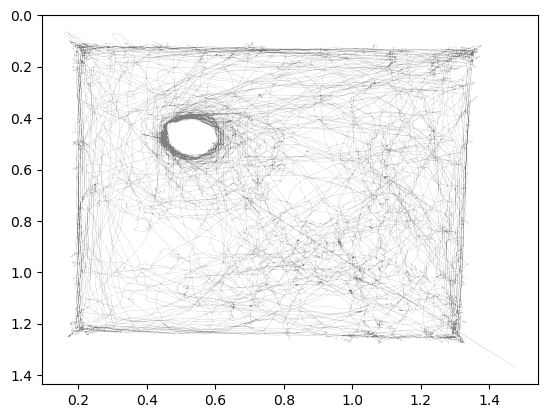

In [17]:
xxx = pd.read_csv('/Users/AdamHarris/Documents/GitRepos/mEC_preprocessing/mEC_preprocessed/openfield/bp01/bp01_2024-04-07-193623.analysi_cleaned_coordinates.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
xxx = pd.read_csv('/Users/AdamHarris/Desktop/big_maze_csvs/CSVs/labels.v004.004_bp01_2024-03-26-191116.analysis.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
xxx = pd.read_csv('/Users/AdamHarris/Desktop/big_maze_csvs/outputs/bp01_2024-03-21-181423.analysis_cleaned_coordinates.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()



In [ ]:
xxx = pd.read_csv('/Users/AdamHarris/Desktop/big_maze_csvs/CSVs/labels.v003.001_bp01_2024-03-21-181423.analysis.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()
